# Two-Stage OTA for Switched-Capacitor Circuits

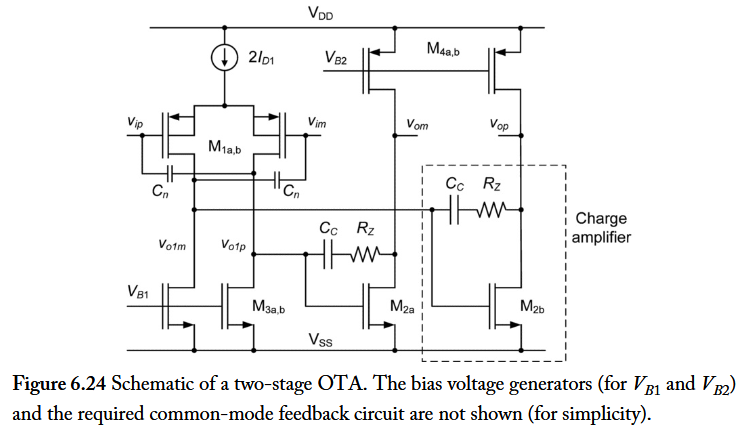

## Step 1 : import libs

In [1]:
import numpy as np
import scipy.constants as sc
import catppuccin
import matplotlib.pyplot as plt
import sys; sys.path.append('../..')
import adri
from pygmid import Lookup as lk
pmos4 = lk('../../lookup_table/035/pmos4.mat')
nmos4 = lk('../../lookup_table/035/nmos4.mat')
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)


## Step 2 : Define Specs

In [2]:
#Design Spec 
s = {
    'G'         : 1/4,
    'FO'        : 4,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 90e-6,
    'vod_final' : 200e-3,
    'L0' : 1000,
    'ts' : 50e-9,
    'ed'    : 0.1/100
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 4.0

# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': 0,
    'cltot_cc': 0,
    'gm_id_test': 0,
    }

## Step 3 : Total current coutour check
Find lowest current with optimal cltot/cc & beta/betamax

cltot_cc_opt      = 0.6483
beta_opt/beta_max = 0.9000
IDtot_opt = 166.6467


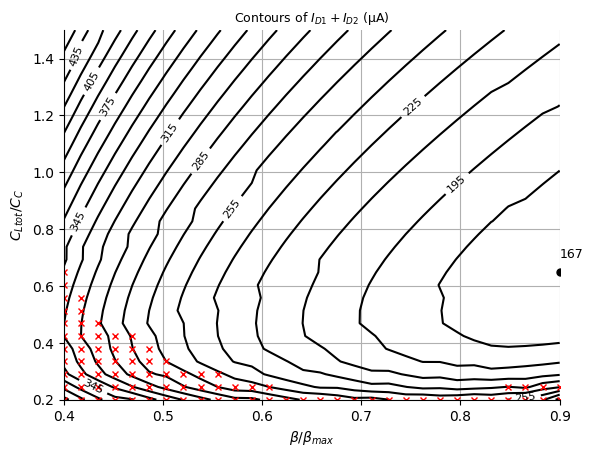

In [3]:
d['beta']       =  beta_max * np.linspace(0.4, 0.9, 30)
d['cltot_cc']   = np.linspace(0.2, 1.5, 30)
d['gm_id_test'] = np.linspace(1, 30, 30)

m1,m2,m3,m4,p = adri.two_stage_sr_opti(nmos4, pmos4, s, d)

ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']
ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)
idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)

IDtot_opt    = ID_TOT[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc'][idx_cl]
beta_opt     = d['beta'][idx_beta]

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

indicator = ID2 < (ID1 * (1+ d['cltot_cc']))

for i in range(len(d['beta'])):
    for j in range(len(d['cltot_cc'])):
            if(indicator[i,j]):
                #print(j)
                ax.plot(d['beta'][i]/beta_max, d['cltot_cc'][j], 'x', markersize=4, color='r')
plt.show()



## Step 4 : Self loading check
Using optimal point found

cltot_cc_opt      = 0.6483
beta_opt/beta_max = 0.9000
IDtot_opt = 960.3607


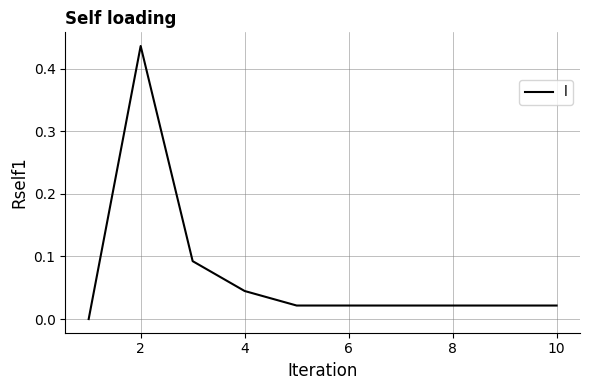

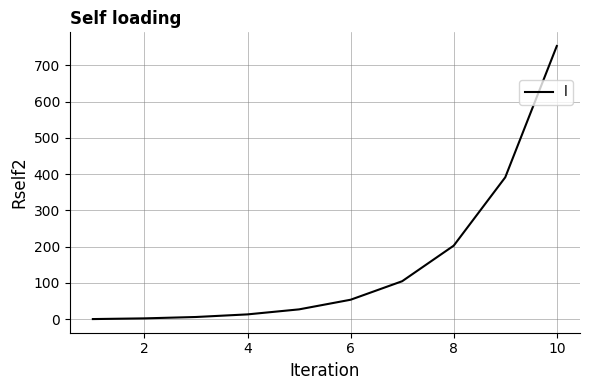

In [ ]:
##Self loading loop
d['beta'] = beta_opt
d['cltot_cc'] = cltot_cc_opt
N_iter = 10
rself1 = np.zeros(N_iter)
rself2 = np.zeros(N_iter)
for i in range(N_iter):

    d['rself_1'] = rself1[i]
    d['rself_2'] = rself2[i]
    
    m1,m2,m3,m4,p = adri.two_stage_sr_opti(nmos4, pmos4, s, d)
    

    if i+1 < N_iter:
        rself1[i+1] = p['rself1'].item()
        rself2[i+1] = p['rself2'].item()

ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2
idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
IDtot_opt    = ID_TOT[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc']
beta_opt     = d['beta']

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

xaxis = np.linspace(1,N_iter, N_iter)
adri.coolPlot(xaxis, rself1, "Iteration", "Rself1", "Self loading")
adri.coolPlot(xaxis, rself2, "Iteration", "Rself2", "Self loading")


## Step 5 : Compute design param with Slew rate optimisation 

In [5]:
###FInal Design
#Design Spec 
##CGS2_CC loop
####Self loading loop
#######test several beta & gm_id to find lowest current point
#=> Take point with lowest current for CGS2_CC

d = {
    'L1': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'L4': 0.5,
    'gam1': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gam4': 0.8,
    'gm3_gm1': 1,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 30),
    'cltot_cc': np.linspace(0.2, 1.5, 30),
    'gm_id_test': np.linspace(1, 30, 30)
    }

#Either sweep variable or use the optimal found before
# d['beta'] = np.array([beta_max * 0.8444])
# d['cltot_cc'] = np.array([0.633])
# d['gm_id_test'] = np.array([15])


cgs2_cc_iter = 8
rself_iter = 5
cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)
cgs2_cc = [0.3]

cgs2_cc_iter = len(cgs2_cc)
rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)
cltot_cc_PLOT = np.zeros(cgs2_cc_iter)
beta_opt_PLOT = np.zeros(cgs2_cc_iter)
GMID_opt_PLOT = np.zeros(cgs2_cc_iter)
rself1_opt_PLOT = np.zeros(cgs2_cc_iter)
rself2_opt_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = adri.two_stage_sr_opti(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    GMID_opt    = m1['gmid'][idx_beta, idx_cl]
    #Plots / cgs_2_cc opti
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]
    cltot_cc_PLOT[k] = cltot_cc_opt
    beta_opt_PLOT[k] = beta_opt
    GMID_opt_PLOT[k] = GMID_opt
    rself1_opt_PLOT[k] = p['rself1'][idx_beta, idx_cl]
    rself2_opt_PLOT[k] = p['rself2'][idx_beta, idx_cl]

idx_min_cgs2_cc_loop = np.argmin(ITOT_PLOT)
#final design
###Take point where current is minimized for cgs2/cc
d['cltot_cc'] = cltot_cc_PLOT[idx_min_cgs2_cc_loop]
d['beta'] = beta_opt_PLOT[idx_min_cgs2_cc_loop]
d['cgs2_cc'] = CGS2_CC_PLOT[idx_min_cgs2_cc_loop]
d['gm_id_test'] = np.unique(GMID_opt_PLOT[idx_min_cgs2_cc_loop])
d['rself_1'] = rself1_opt_PLOT[idx_min_cgs2_cc_loop]
d['rself_2'] = rself2_opt_PLOT[idx_min_cgs2_cc_loop]

m1,m2,m3,m4,p = adri.two_stage_sr_opti(nmos4, pmos4, s, d)
adri.print_design_summary(s, d, p, {}, m1, m2, m3, m4)

# Method 2 : Simplified method

In [6]:
s = {
    'G'         : 1/4,
    'FO'        : 4,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 90e-6,
    'L0' : 10000,
    'ts' : 50e-9,
    'vod_final' : 200e-3,
    'ed'    : 0.1/100
}
# Constants for another design
d = {
    'L1': 0.5,
    'L4': 0.5,
    'L2': 0.5,
    'L3': 0.5,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 10),
    'cltot_cc': np.linspace(0.2, 1.5, 10),
    'gm_id_test': np.linspace(1, 30,15),
    }
#Compute UGBW with settling and error, 
#step 1
s['fu1'] = 1/(2*np.pi) * np.log(1/ s['ed']) / s['ts'] * 1
s['fp2'] = s['fu1'] * 4.0
#step 2
d['rself_1'] = 0.4
d['rself_2'] = 0.4
#step3
d['cgs2_cc'] = 1/3
#step4
beta_max = 1 / (1 + s['G'])
d['beta'] =beta_max * 3/4
#step5
d['cltot_cc'] = 1.3
#step6 -> 10, loop to adjust FU1 and rse
# lf a few time
for i in range(10):
    m1,m2,m3,m4,p = adri.two_stage_sr_opti(nmos4, pmos4, s, d)
    ##Update rself
    d['rself_1'] = p['rself1'].item()
    d['rself_2'] = p['rself2'].item()
    X = s['vod_final'] * d['beta'] / 2 * m1['gmid']
    actual_ts = 1 / s['fu1'] / (2 * np.pi) * (X - 1 + np.log(1/s['ed'] * X))    
    #Update FP1

    wu1 = 1 / s['ts']*(X - 1 + np.log(1/(s['ed']*X)))
    s['fu1'] =  wu1.item() / (2 * np.pi)
    s['fp2'] = s['fu1'] * 4.0
    idtot = (m1['id'] + m2['id'])*1e6

adri.cool_print(idtot,actual_ts, X, wu1, s['fu1'])



#adri.cool_print(idtot, X,wu1,  actual_ts)
adri.print_design_summary(s, d, p, {}, m1, m2, m3, m4)

idtot = array([[541.64898905]])
actual_ts = array([[5.50961892e-08]])
X = array([[1.42714286]])
wu1 = array([[1.39584474e+08]])
s['fu1'] = 22215558.992172074
